In [1]:
# 1. Install system dependencies
!apt-get update && apt-get install -y cmake ninja-build libssl-dev tcpdump

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,968 kB]
Hit:10 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4

In [2]:
# 2. Build liboqs (The core quantum engine)
%cd /content
!rm -rf liboqs oqs-provider
!git clone --depth 1 https://github.com/open-quantum-safe/liboqs.git
%cd liboqs
!cmake -GNinja -B build -DCMAKE_INSTALL_PREFIX=/usr/local -DBUILD_SHARED_LIBS=ON
!ninja -C build install

/content
Cloning into 'liboqs'...
remote: Enumerating objects: 2757, done.
remote: Counting objects: 100% (2757/2757), done.
remote: Compressing objects: 100% (1375/1375), done.
remote: Total 2757 (delta 1537), reused 2028 (delta 1351), pack-reused 0 (from 0)
Receiving objects: 100% (2757/2757), 2.84 MiB | 18.73 MiB/s, done.
Resolving deltas: 100% (1537/1537), done.
/content/liboqs
-- The C compiler identification is GNU 11.4.0
-- The ASM compiler identification is GNU
-- Found assembler: /usr/bin/cc
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Performing Test CC_SUPPORTS_WA_NOEXECSTACK
-- Performing Test CC_SUPPORTS_WA_NOEXECSTACK - Success
-- Performing Test LD_SUPPORTS_WL_Z_NOEXECSTACK
-- Performing Test LD_SUPPORTS_WL_Z_NOEXECSTACK - Success
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD
-- Performing Test CMAKE_HAVE_LIBC_PTHREAD -

In [3]:
# 3. Build oqs-provider (The bridge to OpenSSL)
%cd /content
!git clone --depth 1 https://github.com/open-quantum-safe/oqs-provider.git
%cd oqs-provider
!liboqs_DIR=/usr/local cmake -GNinja -B _build
!ninja -C _build

/content
Cloning into 'oqs-provider'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 169 (delta 24), reused 87 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (169/169), 240.89 KiB | 6.02 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/oqs-provider
CMake Deprecation Warning at CMakeLists.txt:4 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


-- The C compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Cr

In [4]:
# 4. Create the modules directory and move the provider
!mkdir -p /usr/local/lib/ossl-modules
!find _build -name "oqsprovider.so" -exec cp {} /usr/local/lib/ossl-modules/ \;

In [5]:
import os
# Set paths for the current session
os.environ['OPENSSL_MODULES'] = '/usr/local/lib/ossl-modules'
os.environ['LD_LIBRARY_PATH'] = '/usr/local/lib:' + os.environ.get('LD_LIBRARY_PATH', '')

print("Checking for Quantum Provider...")
!openssl list -providers -provider oqsprovider

Checking for Quantum Provider...
Providers:
  oqsprovider
    name: OpenSSL OQS Provider
    version: 0.12.0-dev
    status: active


In [6]:
# Generate the Private Key
!openssl genpkey -provider oqsprovider -provider default \
    -algorithm mldsa65 -out pqc_ca.key

# Generate the Certificate
!openssl req -x509 -new -provider oqsprovider -provider default \
    -key pqc_ca.key -out pqc_ca.crt -nodes -days 365 \
    -subj "/C=BD/ST=Dhaka/L=Dhaka/O=NoshinLab/CN=QuantumIDS.local"

In [13]:
import subprocess
import time
import os

# 1. Cleanup: Kill any lingering processes from previous runs
os.system("pkill -9 openssl")
os.system("pkill -9 tcpdump")
time.sleep(1)

print("--- Starting Quantum Sandbox ---")

--- Starting Quantum Sandbox ---


In [14]:
# 2. Start the Quantum Server in the background
# -propquery forces the use of the OQS provider for the handshake
server_cmd = [
    "openssl", "s_server",
    "-provider", "oqsprovider", "-provider", "default",
    "-propquery", "provider=oqsprovider",
    "-cert", "pqc_ca.crt", "-key", "pqc_ca.key",
    "-tls1_3", "-groups", "mlkem768", "-www", "-accept", "4433"
]
server_proc = subprocess.Popen(server_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("1. Quantum Server listening on port 4433...")

1. Quantum Server listening on port 4433...


In [15]:
# 3. Start Packet Capture
# -U (packet-buffered) prevents the "Broken Pipe" error by flushing data immediately
print("2. Starting Packet Capture (tcpdump)...")
cap_cmd = ["tcpdump", "-i", "lo", "-U", "-w", "quantum_data.pcap", "port", "4433"]
cap_proc = subprocess.Popen(cap_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(2)

2. Starting Packet Capture (tcpdump)...


In [16]:
# 4. Generate Traffic
print("3. Simulating 50 Quantum Handshakes...")
for i in range(50):
    # s_client connects, performs the handshake, and immediately exits
    os.system("openssl s_client -connect localhost:4433 -provider oqsprovider -provider default -groups mlkem768 -brief < /dev/null > /dev/null 2>&1")
    if (i+1) % 10 == 0:
        print(f"   Progress: {i+1}/50 handshakes complete")

3. Simulating 50 Quantum Handshakes...
   Progress: 10/50 handshakes complete
   Progress: 20/50 handshakes complete
   Progress: 30/50 handshakes complete
   Progress: 40/50 handshakes complete
   Progress: 50/50 handshakes complete


In [17]:
# 5. Safe Shutdown
print("4. Finalizing and saving data...")
time.sleep(3) # Wait for the last packets to finish traversing the pipe

4. Finalizing and saving data...


In [18]:
# 5. Safe Shutdown
print("4. Finalizing and saving data...")
time.sleep(3) # Wait for the last packets to finish traversing the pipe

# Terminate processes gracefully
cap_proc.terminate()
server_proc.terminate()

# Wait for tcpdump to finish writing the .pcap file
try:
    cap_proc.wait(timeout=5)
    print("5. Success! 'quantum_data.pcap' is ready for analysis.")
except subprocess.TimeoutExpired:
    cap_proc.kill()
    print("5. Capture process forced to stop. Checking file...")

# Verify file size
size = os.path.getsize("quantum_data.pcap")
print(f"Final file size: {size / 1024:.2f} KB")

4. Finalizing and saving data...
5. Success! 'quantum_data.pcap' is ready for analysis.
Final file size: 15.65 KB


In [25]:
import subprocess
import time
import os

# 1. Cleanup: Kill any lingering processes
os.system("pkill -9 openssl")
os.system("pkill -9 tcpdump")
time.sleep(1)

print("--- Starting Classical (Attack) Simulation ---")

# 2. Start the Server using a CLASSICAL group (x25519)
# This simulates traffic that is NOT quantum-resistant
server_cmd = [
    "openssl", "s_server",
    "-cert", "pqc_ca.crt", "-key", "pqc_ca.key",
    "-tls1_3", "-groups", "x25519", "-www", "-accept", "4433"
]
server_proc = subprocess.Popen(server_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("1. Classical Server listening on port 4433...")

# 3. Start Packet Capture for the "Classical" file
print("2. Starting Packet Capture (classical_data.pcap)...")
cap_proc = subprocess.Popen(["tcpdump", "-i", "lo", "-U", "-w", "classical_data.pcap", "port", "4433"])
time.sleep(2)

# 4. Generate 50 Classical Handshakes
print("3. Simulating 50 Classical (Vulnerable) Handshakes...")
for i in range(50):
    # Using x25519 instead of mlkem768
    os.system("openssl s_client -connect localhost:4433 -groups x25519 -brief < /dev/null > /dev/null 2>&1")
    if (i+1) % 10 == 0:
        print(f"   Progress: {i+1}/50 complete")

# 5. Shutdown
time.sleep(3)
cap_proc.terminate()
server_proc.terminate()

print("--- Done! 'classical_data.pcap' created successfully ---")

--- Starting Classical (Attack) Simulation ---
1. Classical Server listening on port 4433...
2. Starting Packet Capture (classical_data.pcap)...
3. Simulating 50 Classical (Vulnerable) Handshakes...
   Progress: 10/50 complete
   Progress: 20/50 complete
   Progress: 30/50 complete
   Progress: 40/50 complete
   Progress: 50/50 complete
--- Done! 'classical_data.pcap' created successfully ---


In [19]:
!tcpdump -X -r quantum_data.pcap | head -n 20

reading from file quantum_data.pcap, link-type EN10MB (Ethernet), snapshot length 262144
10:42:15.277602 IP localhost.51062 > localhost.4433: Flags [S], seq 2471390072, win 65495, options [mss 65495,sackOK,TS val 3702894747 ecr 0,nop,wscale 7], length 0
	0x0000:  4500 003c 1ce6 4000 4006 1fd4 7f00 0001  E..<..@.@.......
	0x0010:  7f00 0001 c776 1151 934e 6b78 0000 0000  .....v.Q.Nkx....
	0x0020:  a002 ffd7 fe30 0000 0204 ffd7 0402 080a  .....0..........
	0x0030:  dcb5 b09b 0000 0000 0103 0307            ............
10:42:15.277611 IP localhost.4433 > localhost.51062: Flags [R.], seq 0, ack 2471390073, win 0, length 0
	0x0000:  4500 0028 0000 4000 4006 3cce 7f00 0001  E..(..@.@.<.....
	0x0010:  7f00 0001 1151 c776 0000 0000 934e 6b79  .....Q.v.....Nky
	0x0020:  5014 0000 da3e 0000                      P....>..
10:42:15.277635 IP localhost.51078 > localhost.4433: Flags [S], seq 1868160035, win 65495, options [mss 65495,sackOK,TS val 3702894747 ecr 0,nop,wscale 7], length 0
	0x0000:  450

In [20]:
!pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.4 MB/s eta 0:00:00


In [21]:
from scapy.all import rdpcap, IP, TCP
import pandas as pd

def extract_features(pcap_file):
    packets = rdpcap(pcap_file)
    data = []

    # We group packets into "Flows" (source -> destination)
    # For this lab, we just extract per-packet statistics
    for i, pkt in enumerate(packets):
        if IP in pkt and TCP in pkt:
            feature_row = {
                "packet_index": i,
                "src_ip": pkt[IP].src,
                "dst_ip": pkt[IP].dst,
                "length": len(pkt),
                "timestamp": float(pkt.time),
                "tcp_flags": int(pkt[TCP].flags),
                "payload_size": len(pkt[TCP].payload)
            }
            data.append(feature_row)

    return pd.DataFrame(data)

# Run extraction
df = extract_features("quantum_data.pcap")

# Calculate "Inter-Arrival Time" (IAT) - crucial for PQC timing analysis
df['iat'] = df['timestamp'].diff().fillna(0)

print(df.head())
df.to_csv("pqc_features.csv", index=False)

   packet_index     src_ip     dst_ip  length     timestamp  tcp_flags  \
0             0  127.0.0.1  127.0.0.1      74  1.776336e+09          2   
1             1  127.0.0.1  127.0.0.1      54  1.776336e+09         20   
2             2  127.0.0.1  127.0.0.1      74  1.776336e+09          2   
3             3  127.0.0.1  127.0.0.1      54  1.776336e+09         20   
4             4  127.0.0.1  127.0.0.1      74  1.776336e+09          2   

   payload_size       iat  
0             0  0.000000  
1             0  0.000009  
2             0  0.000024  
3             0  0.000002  
4             0  0.006902  


In [26]:
# 1. Process the Quantum Data
print("Extracting Quantum features...")
df_quantum = extract_features("quantum_data.pcap")
df_quantum['iat'] = df_quantum['timestamp'].diff().fillna(0)
df_quantum['label'] = 1  # 1 = Safe/Quantum-Ready

# 2. Process the Classical Data
print("Extracting Classical (Attack) features...")
df_attack = extract_features("classical_data.pcap")
df_attack['iat'] = df_attack['timestamp'].diff().fillna(0)
df_attack['label'] = 0  # 0 = Vulnerable/Potential Attack

# 3. Combine into a Master Dataset
df_final = pd.concat([df_quantum, df_attack], ignore_index=True)

# 4. Shuffle the data
# This is critical so the model doesn't learn based on the order of rows
df_final = df_final.sample(frac=1).reset_index(drop=True)

# 5. Final Check
print(f"Success! Final dataset contains {len(df_final)} packets.")
print(df_final['label'].value_counts()) # Should show a balance of 0s and 1s
df_final.to_csv("ids_master_dataset.csv", index=False)

Extracting Quantum features...
Extracting Classical (Attack) features...
Success! Final dataset contains 400 packets.
label
0    200
1    200
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select the features the AI will look at
# We exclude IP addresses and timestamps because those change.
# We focus on the 'physics' of the packet.
features = ['length', 'payload_size', 'iat', 'tcp_flags']
X = df_final[features]
y = df_final['label']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and Train the Random Forest
# n_estimators=100 means we are using 100 "Decision Trees" to vote on the result
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("--- IDS Model Training Complete ---")

--- IDS Model Training Complete ---



--- Performance Report ---
                    precision    recall  f1-score   support

Attack (Classical)       0.60      0.86      0.71        37
    Safe (Quantum)       0.81      0.51      0.63        43

          accuracy                           0.68        80
         macro avg       0.71      0.69      0.67        80
      weighted avg       0.72      0.68      0.67        80



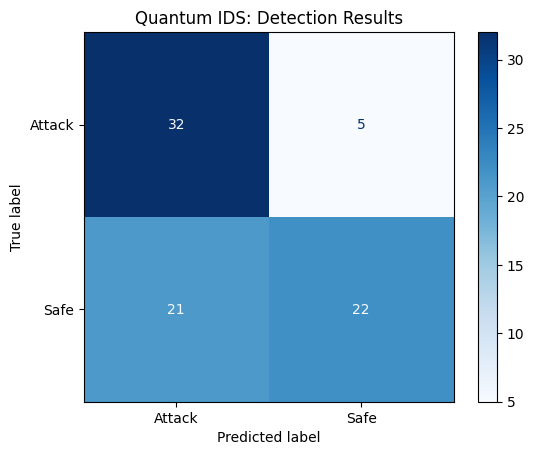

In [28]:
# 4. Make predictions on the test set
y_pred = clf.predict(X_test)

# 5. Show the Accuracy Report
print("\n--- Performance Report ---")
print(classification_report(y_test, y_pred, target_names=['Attack (Classical)', 'Safe (Quantum)']))

# 6. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Attack', 'Safe'])
disp.plot(cmap='Blues')
plt.title('Quantum IDS: Detection Results')
plt.show()

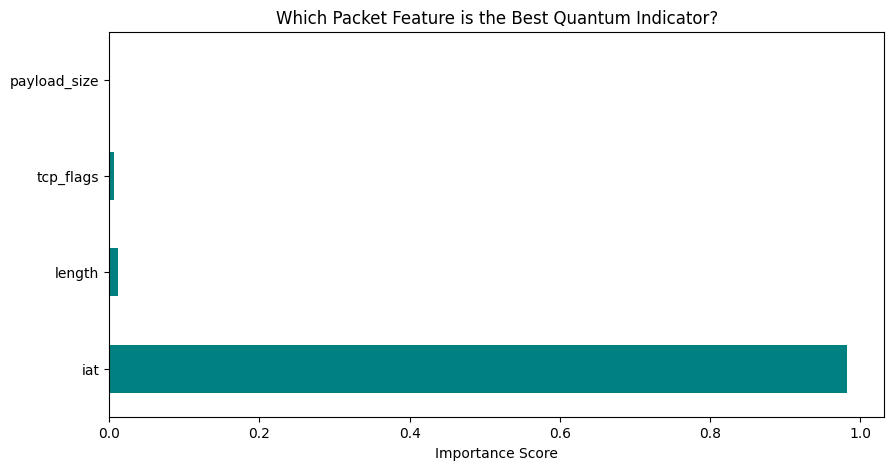

In [29]:
import pandas as pd
import seaborn as sns

# Get the importance scores
importances = clf.feature_importances_
feat_importances = pd.Series(importances, index=features)

# Plot
plt.figure(figsize=(10,5))
feat_importances.nlargest(4).plot(kind='barh', color='teal')
plt.title('Which Packet Feature is the Best Quantum Indicator?')
plt.xlabel('Importance Score')
plt.show()

In [30]:
import joblib
joblib.dump(clf, 'pqc_ids_model.pkl')
print("Model saved as pqc_ids_model.pkl")

Model saved as pqc_ids_model.pkl
